# PFDA Project
## ECommerce & consumer behaviour

**About the File**

Sales and promotion information on five products from three brands within four categories (mouthwash, pretzels, frozen pizza, and boxed cereal) over 156 weeks.

* Used for time series analysis, including: Price sensitivity, promotional effectiveness, comparing/contrasting categories or stores.

Source: [Customer Shopping Trends Dataset](https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset)

Why was this chosen? 

I have a strong academic background in marketing, it was my favourite subject in College -- this topic is all about Big Data and data analysis. 

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import seaborn as sns

# Confirmation message
print("Libraries loaded successfully!")

Libraries loaded successfully!


### Data Summary

In [2]:
# Define file path and name
FILENAME = "shopping_trends_1.csv"
DATADIR = "data/"
FULLPATH = DATADIR + FILENAME

# Read the CSV file into a Data Frame
# The data file has 22 rows of metadata at the top, so we skip those
df = pd.read_csv(FULLPATH)

display (df.head())

# Data was taken from https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
# Display basic information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [4]:
# We'll also check if there are any missing values in the dataset
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [5]:
# Because there are only 69 values missing in the 'Age' column, we can drop those rows
df = df.dropna(subset=['Age'])

In [38]:
# Also, for better analysis, we'll create an 'Age Group' column
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

In [7]:
# And, we'll change the Fall season to Autumn for consistency
df['Season'] = df['Season'].replace('Fall', 'Autumn')

In [8]:
# Show summary statistics of the DataFrame
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


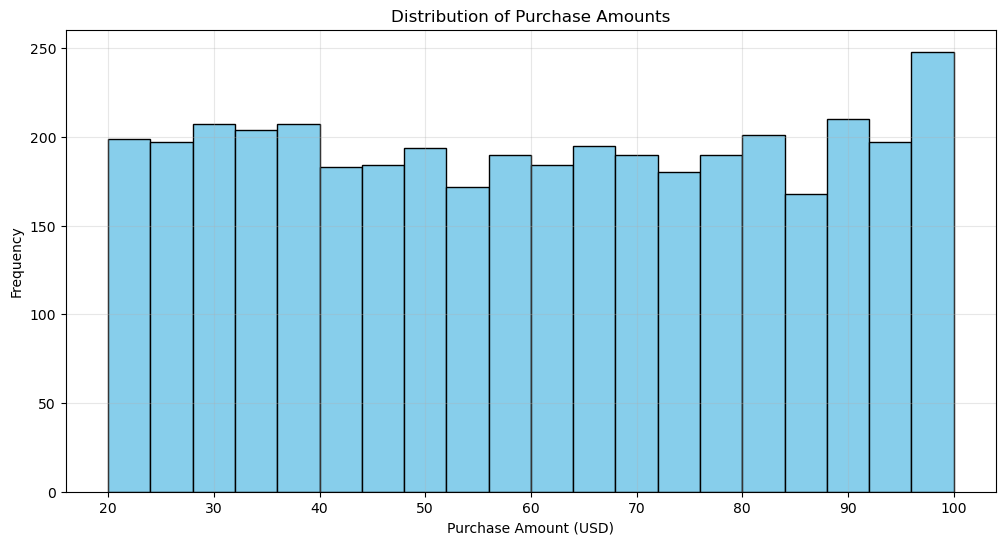

In [9]:
# Now, we can have a look at the purchasing amounts
plt.figure(figsize=(12,6))
plt.hist(df['Purchase Amount (USD)'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Purchase Amounts')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

C:\Users\35387\AppData\Local\Temp\ipykernel_3516\2531944414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette='pastel', edgecolor='black')


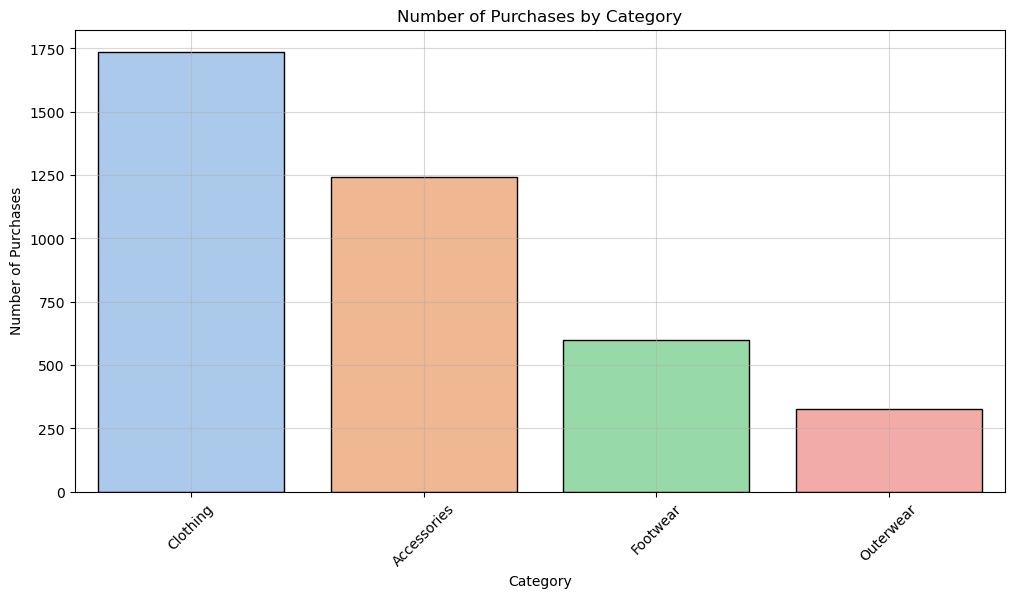

In [10]:
# And purchases by category
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette='pastel', edgecolor='black')
plt.title('Number of Purchases by Category')
plt.xlabel('Category')
plt.ylabel('Number of Purchases')
plt.grid(alpha=0.5)
plt.xticks(rotation=45)
plt.show()

### Gender Distribution

In [11]:
# Let's take a look at gender distribution
df['Gender'].value_counts()

Gender
Male      2652
Female    1248
Name: count, dtype: int64

In [12]:
# And in percentages
df['Gender'].value_counts(normalize=True) * 100

Gender
Male      68.0
Female    32.0
Name: proportion, dtype: float64

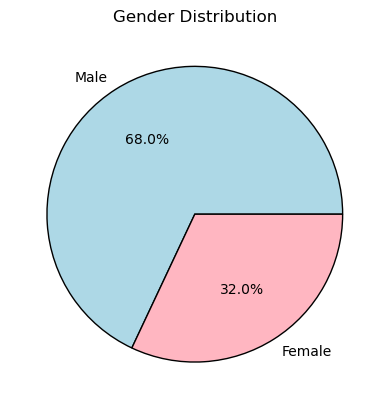

In [13]:
# We'll create a pie chart for gender distribution
plt.pie(df['Gender'].value_counts(), labels=df['Gender'].value_counts().index, autopct='%1.1f%%', colors=['lightblue', 'lightpink'], wedgeprops={'edgecolor': 'black'})

plt.title('Gender Distribution')
plt.ylabel('')  # Hide y-label for better aesthetics
plt.show()


### Top items purchased

In [14]:
# Top 10 most purchased items
df['Item Purchased'].value_counts().head(10)

Item Purchased
Blouse        171
Jewelry       171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Belt          161
Sunglasses    161
Coat          161
Name: count, dtype: int64

### Purchase Amount by Category

In [15]:
# Average, total, and count of purchases per category
df.groupby('Category')['Purchase Amount (USD)'].agg(['mean', 'sum', 'count'])

,mean,sum,count
Category,,,
Accessories,59.838710,74200,1240
Clothing,60.025331,104264,1737
Footwear,60.255426,36093,599
Outerwear,57.172840,18524,324


### Age Group Analysis

In [17]:
pd.cut(df['Age'], bins=[18,30,45,60,70], labels=['Young', 'Adult', 'Middle', 'Senior'])

0       Middle
1        Young
2       Middle
3        Young
4        Adult
         ...  
3895     Adult
3896    Middle
3897    Middle
3898     Adult
3899    Middle
Name: Age, Length: 3900, dtype: category
Categories (4, object): ['Young' < 'Adult' < 'Middle' < 'Senior']

In [18]:
pd.cut(df['Age'], bins=[18,30,45,60,70], labels=['Young', 'Adult', 'Middle', 'Senior']).value_counts()

Age
Middle    1135
Adult     1093
Young      880
Senior     723
Name: count, dtype: int64

### Top Locations for Purchases

In [20]:
# Group by location with for a table of total spending by top 10 states
df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False).head(10)

Location
Montana          5784
Illinois         5617
California       5605
Idaho            5587
Nevada           5514
Alabama          5261
New York         5257
North Dakota     5220
West Virginia    5174
Nebraska         5172
Name: Purchase Amount (USD), dtype: int64

### Seasonal Purchase Trends


In [21]:
# number of purchases per season
df.groupby('Season')['Item Purchased'].count()

Season
Autumn    975
Spring    999
Summer    955
Winter    971
Name: Item Purchased, dtype: int64

In [22]:
# We'll take a look at average purchase amount by season
df.groupby('Season')['Purchase Amount (USD)'].mean()

Season
Autumn    61.556923
Spring    58.737738
Summer    58.405236
Winter    60.357364
Name: Purchase Amount (USD), dtype: float64

In [23]:
# And we'll take a look at average purchase amount by season and location
df.groupby(['Season','Location'])['Purchase Amount (USD)'].mean()

Season  Location     
Autumn  Alabama          53.625000
        Alaska           72.533333
        Arizona          75.000000
        Arkansas         56.578947
        California       61.444444
                           ...    
Winter  Virginia         70.080000
        Washington       62.437500
        West Virginia    56.190476
        Wisconsin        55.052632
        Wyoming          69.318182
Name: Purchase Amount (USD), Length: 200, dtype: float64

In [41]:
# Finally, we'll take a look at the top 5 locations for each season
df.groupby('Season')['Location'].apply(lambda x: x.value_counts().head(5))

Season                
Autumn  South Carolina    27
        California        27
        Texas             26
        New York          25
        Idaho             25
Spring  Nevada            28
        Alaska            27
        North Carolina    27
        Idaho             26
        Maryland          26
Summer  Pennsylvania      27
        North Dakota      27
        Nevada            27
        Montana           26
        Idaho             26
Winter  Vermont           31
        Oklahoma          27
        Maine             26
        Kentucky          25
        Montana           25
Name: Location, dtype: int64

### Review Rating Distribution

In [43]:
# And we'll also check the review rating by gender
df.groupby('Gender')['Review Rating'].mean()

Gender
Female    3.741426
Male      3.753959
Name: Review Rating, dtype: float64

In [44]:
# Comparing average previous purchases between subscribers and non-subscribers
df.groupby('Subscription Status')['Previous Purchases'].mean()

Subscription Status
No     25.080436
Yes    26.084520
Name: Previous Purchases, dtype: float64

### Payment Method Preferences

In [27]:
# Payment method distribution
df['Payment Method'].value_counts()

Payment Method
Credit Card      696
Venmo            653
Cash             648
PayPal           638
Debit Card       633
Bank Transfer    632
Name: count, dtype: int64

In [28]:
# Adding Gender vs Payment Method crosstab
pd.crosstab(df['Gender'], df['Payment Method'])

Payment Method,Bank Transfer,Cash,Credit Card,Debit Card,PayPal,Venmo
Gender,,,,,,
Female,204,197,223,207,203,214
Male,428,451,473,426,435,439


In [30]:
# Average spend and volume with/without discounts
df.groupby('Discount Applied')['Purchase Amount (USD)'].agg(['mean', 'count'])

,mean,count
Discount Applied,,
No,60.130454,2223
Yes,59.279070,1677


### Color Preferences by Gender

In [31]:
# Top 10 colours by gender
pd.crosstab(df['Color'], df['Gender']).head(10)

Gender,Female,Male
Color,,
Beige,40,107
Black,54,113
Blue,52,100
Brown,46,95
Charcoal,50,103
Cyan,47,119
Gold,41,97
Gray,53,106
Green,56,113


In [32]:
# Top 10 most common items purchased with discount
df[df['Discount Applied'] == 'Yes']['Item Purchased'].value_counts().head(10)

Item Purchased
Pants       81
Coat        79
Sweater     79
Hat         77
Jewelry     76
Dress       75
Sneakers    72
Belt        72
Shirt       71
Shorts      68
Name: count, dtype: int64

In [33]:
# We'll take a look at the most common items purchased without discount
df[df['Discount Applied'] == 'No']['Item Purchased'].value_counts().head(10)

Item Purchased
Blouse        113
Socks         107
Sandals       101
Shirt          98
Jacket         98
Skirt          97
Sunglasses     95
Jewelry        95
Handbag        92
Dress          91
Name: count, dtype: int64

### Age vs. Purchase Amount Correlation